In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


### We assume that both dataset and files generated by files for data preparation (00 to 06 files provided) are present in the working directory of this notebook 

Code,City

01,Ottawa,

07,Moscow

02,Houston,

08,Istanbul

03,Bogota,

09,Daegu

04,Manizales,

10,Sintra

06,Helsinki,

11,Suzhou

Gender 

1.0 - Female 

2.0 - Male 

Cohort

1.0 - younger ~10 years old

2.0 - older ~15 years old

In [2]:
# --- SETTINGS ---
n_clusters = 3
grade_cols = ['ST_Sgrade_Math', 'ST_Sgrade_Read_Lang', 'ST_Sgrade_Arts']
weight_col = 'PA_WT2019_PA'   # weights from parent dataset

# --- 1. DATA LOADING & FILTERING ---
df = pd.read_csv("INT_Final_Merged_Prefixed.csv")
df_st_filter = pd.read_csv("data_full_data_withoutArts.csv")
df = df[df['Username_Std'].isin(df_st_filter['Username_Std'])]

# here different sites cohort and gender might be chosen -> here setting for older male cohort from Bogota
df_sub = df[
    (df['ST_SiteID'] == 4.0) & 
    (df['ST_CohortID'] == 2.0) & 
    (df['ST_Gender_Std'] == 2.0)
].copy()


features = [
    "ST_RES_WLE_ADJ", "ST_SEL_WLE_ADJ", "ST_PER_WLE_ADJ", "ST_st_relteach", 
    "ST_st_bully", "ST_st_belong", "ST_st_friends", "ST_st_relpar", 
    "ST_st_wellbeing", "ST_st_anxtest", "ST_SES" ,
    "PA_pa_comm", "PA_pa_wellbeing", "PA_pa_engage", "PA_pa_encour"
]
df_clean = df_sub[features + grade_cols + [weight_col]].dropna().reset_index(drop=True)
print(f"Number of students after clearing dataset: {len(df_clean)}")


Number of students after clearing dataset: 1141


### PREPARATION & WEIGHT RESCALING 

In [3]:

n_sample = len(df_clean)
sum_weights = df_clean[weight_col].sum()
# Rescaling weight so sum(weights) == N
df_clean['Rescaled_Weight'] = df_clean[weight_col] * (n_sample / sum_weights)

weights = df_clean['Rescaled_Weight'].values
X_raw = df_clean[features].values

### STANDARDIZATION & PCA

In [4]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

# Apply Square Root Weighting for PCA calculation
w_sqrt = np.sqrt(weights).reshape(-1, 1)
X_weighted_std = X_std * w_sqrt 

pca = PCA(n_components=2)
X_pca_data = pca.fit_transform(X_weighted_std)

# Store loadings for the Heatmap
loadings_df = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=features
)

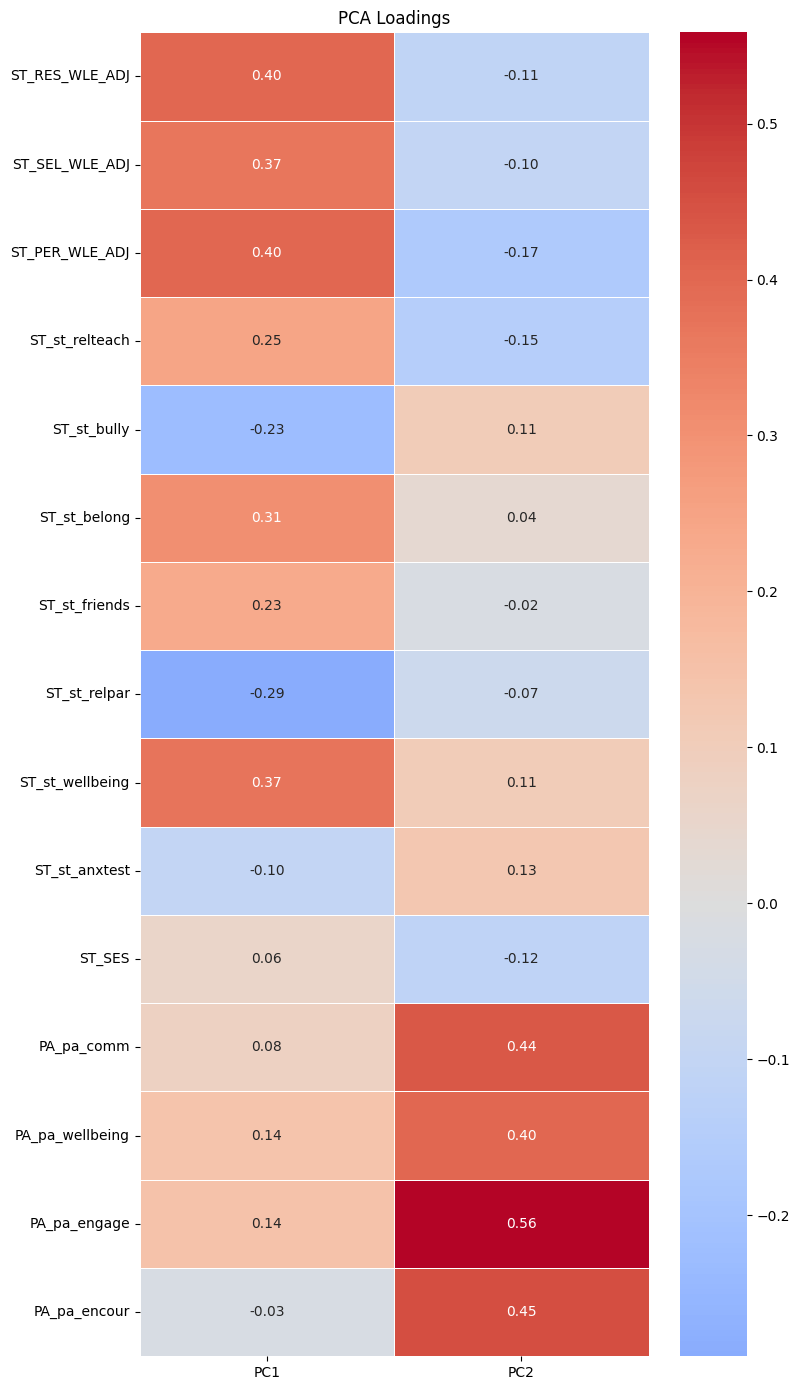

In [5]:
plt.figure(figsize=(8, 14))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('PCA Loadings')
plt.tight_layout()

plt.show()

C:\Users\akopa\AppData\Local\Temp\ipykernel_37024\1315565073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pca1_data, x='Feature', y='Loading', palette='RdBu_r')


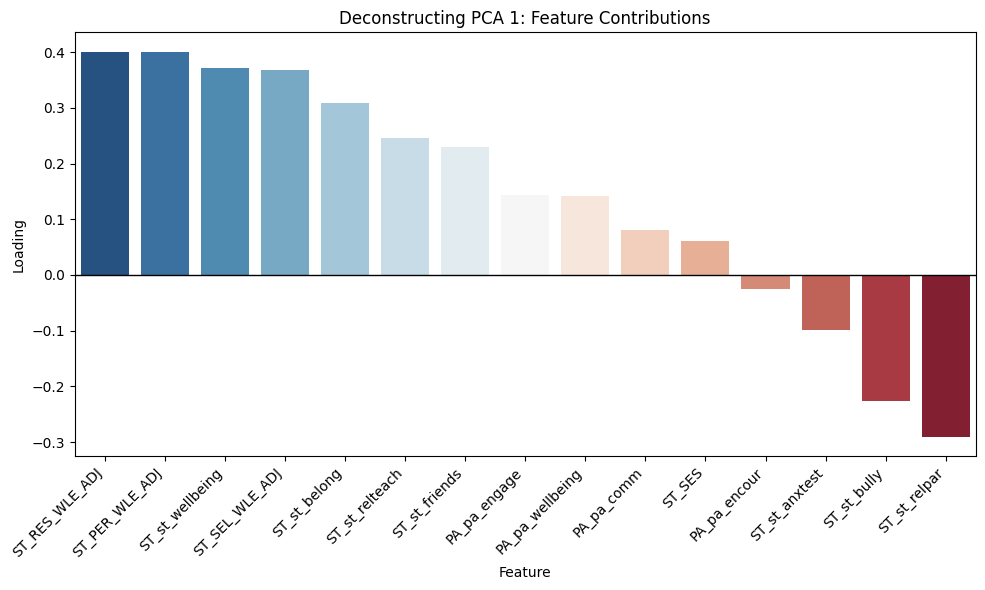

In [6]:

loadings_melted = loadings_df.reset_index().melt(id_vars='index', var_name='PC', value_name='Loading')
loadings_melted.rename(columns={'index': 'Feature'}, inplace=True)

plt.figure(figsize=(10, 6))
pca1_data = loadings_melted[loadings_melted['PC'] == 'PC1'].sort_values(by='Loading', ascending=False)
sns.barplot(data=pca1_data, x='Feature', y='Loading', palette='RdBu_r')
plt.title(f"Deconstructing PCA 1: Feature Contributions")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

C:\Users\akopa\AppData\Local\Temp\ipykernel_37024\322950886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pca2_data, x='Feature', y='Loading', palette='BrBG')


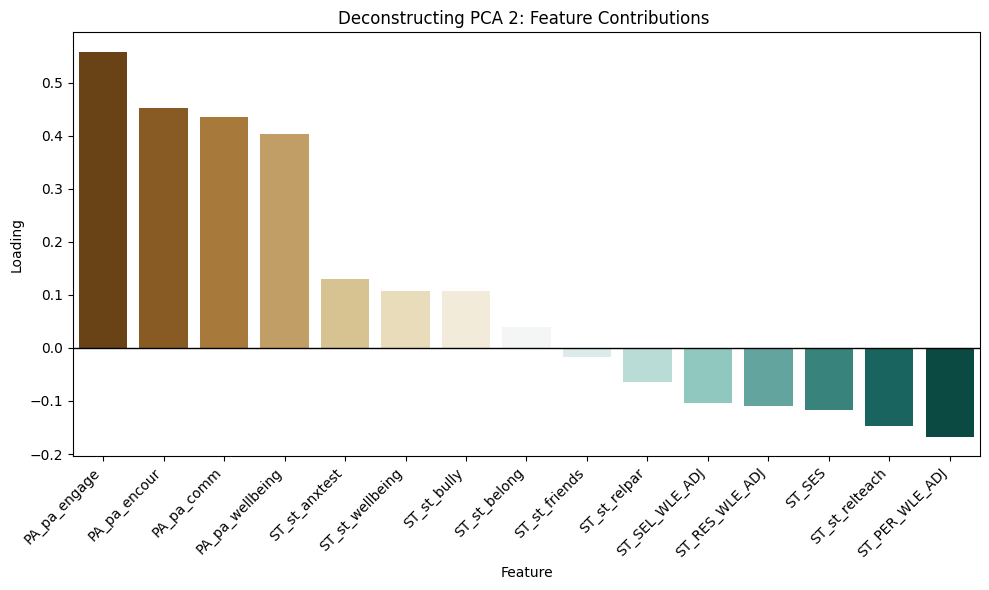

In [8]:
plt.figure(figsize=(10, 6))
pca2_data = loadings_melted[loadings_melted['PC'] == 'PC2'].sort_values(by='Loading', ascending=False)
sns.barplot(data=pca2_data, x='Feature', y='Loading', palette='BrBG')
plt.title(f"Deconstructing PCA 2: Feature Contributions ")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

### Clustering

In [9]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
raw_clusters = kmeans.fit_predict(X_pca_data, sample_weight=weights)
cluster_pca1_means = []
for i in range(n_clusters):
    mask = (raw_clusters == i)
    w_avg_pca1 = np.average(X_pca_data[mask, 0], weights=weights[mask])
    cluster_pca1_means.append((i, w_avg_pca1))

sorted_clusters = sorted(cluster_pca1_means, key=lambda x: x[1])
mapping = {old_idx: new_idx for new_idx, (old_idx, _) in enumerate(sorted_clusters)}
final_clusters = np.array([mapping[c] for c in raw_clusters])

df_clean['Cluster'] = final_clusters
df_clean['PCA1'] = X_pca_data[:, 0]
df_clean['PCA2'] = X_pca_data[:, 1]


c:\Users\akopa\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Nie można odnaleźć określonego pliku
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\akopa\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\akopa\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\akopa\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File 

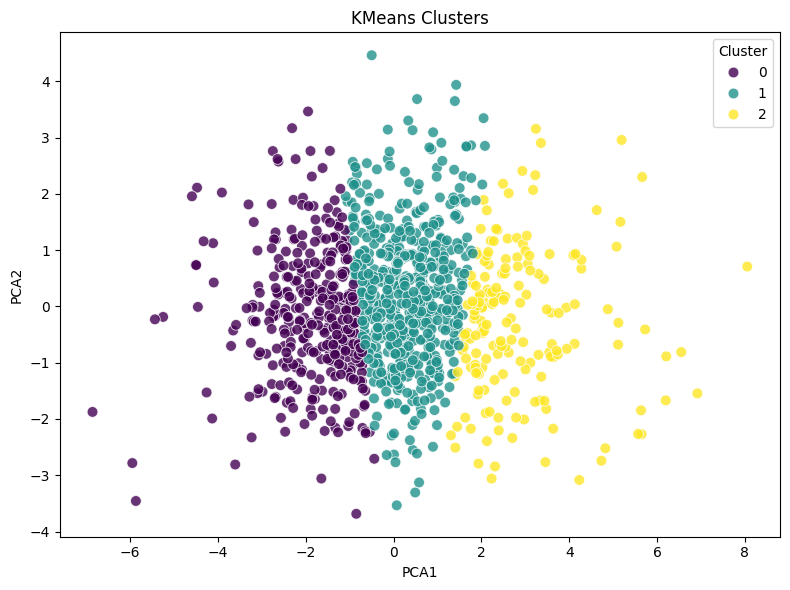

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_clean, palette='viridis', s=60, alpha=0.8)
plt.title('KMeans Clusters')
plt.tight_layout()
plt.show()


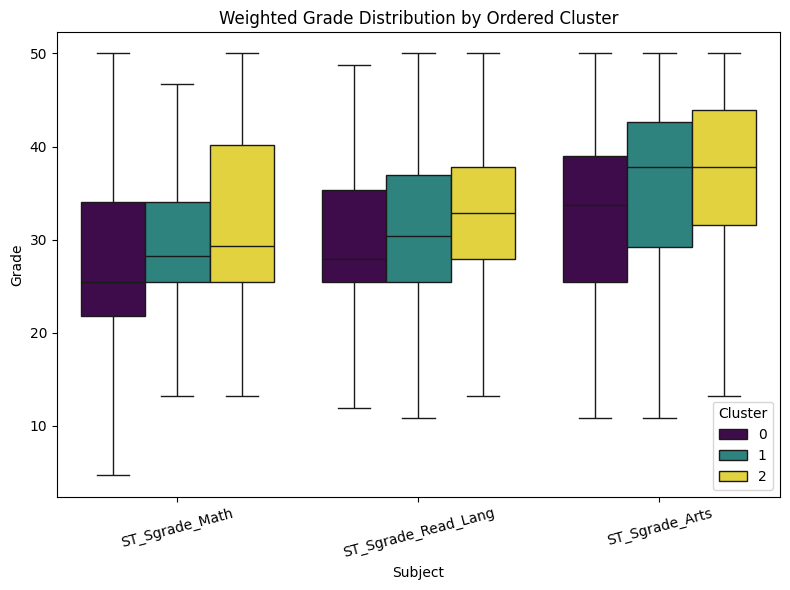

In [12]:
plt.figure(figsize=(8, 6))
df_resampled = df_clean.sample(n=len(df_clean), replace=True, weights='Rescaled_Weight', random_state=42)
df_melted_weighted = df_resampled.melt(id_vars=['Cluster'], value_vars=grade_cols, var_name='Subject', value_name='Grade')

sns.boxplot(x='Subject', y='Grade', hue='Cluster', data=df_melted_weighted, palette='viridis', showfliers=False)
plt.title('Weighted Grade Distribution by Ordered Cluster')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [13]:
print("\nWeighted Average Grades by Cluster")
for cluster_id in range(n_clusters):
    subset = df_clean[df_clean['Cluster'] == cluster_id]
    if len(subset) > 0:
        w_avg_math = np.average(subset['ST_Sgrade_Math'], weights=subset['Rescaled_Weight'])
        w_avg_read = np.average(subset['ST_Sgrade_Read_Lang'], weights=subset['Rescaled_Weight'])
        w_avg_art = np.average(subset['ST_Sgrade_Arts'], weights=subset['Rescaled_Weight'])
        print(f"Cluster {cluster_id}: Math={w_avg_math:.2f}, Read={w_avg_read:.2f}, Art={w_avg_art:.2f}, N={len(subset)}")


Weighted Average Grades by Cluster
Cluster 0: Math=27.65, Read=28.73, Art=32.90, N=365
Cluster 1: Math=29.61, Read=30.76, Art=35.42, N=597
Cluster 2: Math=32.08, Read=32.57, Art=36.95, N=179


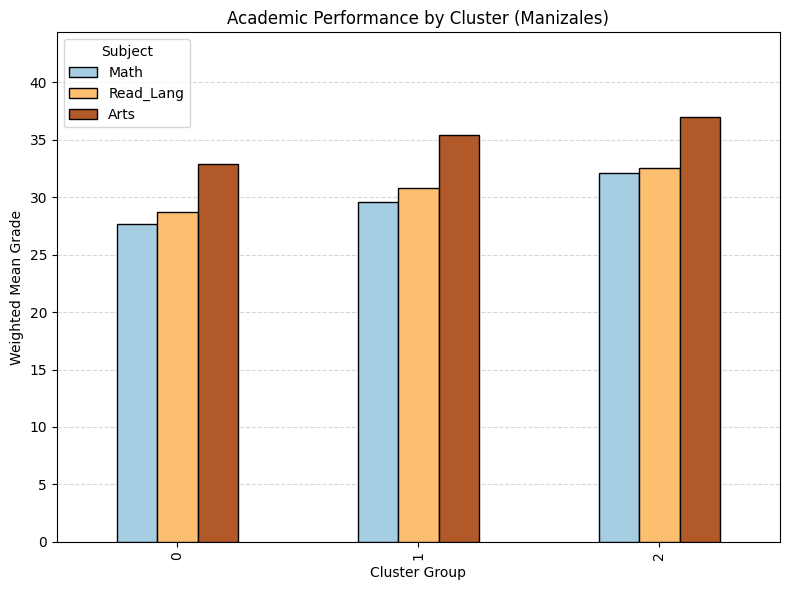

In [15]:
cluster_stats = []
for cluster_id in range(n_clusters):
    subset = df_clean[df_clean['Cluster'] == cluster_id]
    if len(subset) > 0:
        row = {'Cluster': cluster_id}
        for col in grade_cols:
            row[col] = np.average(subset[col], weights=subset['Rescaled_Weight'])
        cluster_stats.append(row)

profile_plot_data = pd.DataFrame(cluster_stats).set_index('Cluster').sort_index()


profile_plot_data.columns = [c.replace('ST_Sgrade_', '') for c in profile_plot_data.columns]

fig, ax = plt.subplots(figsize=(8, 6))

profile_plot_data.plot(
    kind='bar', 
    ax=ax, 
    colormap='Paired', 
    edgecolor='black', 
    zorder=3
)

# 4. Styling based on your provided layout
ax.set_title(f'Academic Performance by Cluster (Manizales)')
ax.set_ylabel('Weighted Mean Grade')
ax.set_xlabel('Cluster Group')

# Note: Adjust ylim (e.g., 0, 50 or 0, 5) based on your specific grade scale
ax.set_ylim(0, profile_plot_data.values.max() * 1.2) 

ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.legend(title='Subject', loc='upper left')

# 5. Save and Close
plt.tight_layout()
plt.show()


